# Regresión Lineal LASSO - RIDGE
- Son dos modelos: Lasso y Ridge
- Funciona muy bien cuando son muchas variables y hay alguna muy correlacionada

#### El problema que resuelven
- *Imagina que estás construyendo un modelo de regresión lineal para predecir, por ejemplo, el CLV (Customer Lifetime Value) de un cliente a partir de 40 variables: edad, gasto medio, frecuencia de compra, canal de adquisición, etc.*
- *Con tantas variables, la regresión lineal clásica tiende a sobreajustar (overfitting): encuentra coeficientes muy grandes que se ajustan perfectamente a tus datos históricos pero fallan al predecir clientes nuevos. El modelo "memoriza" ruido en lugar de aprender el patrón real.*
- *Ridge y Lasso resuelven esto añadiendo una penalización a los coeficientes grandes durante el entrenamiento. Es como decirle al modelo: "ajústate bien a los datos, pero no te vuelvas loco con los coeficientes".*

#### La diferencia en una frase
- Ridge reduce el peso de todas las variables por igual. 
- Lasso decide qué variables sobran y las descarta.

### Ridge (penalización L2)

- Ridge castiga la suma de los coeficientes al cuadrado. El efecto: encoge todos los coeficientes hacia cero, pero nunca los deja exactamente en cero. Todas las variables se quedan en el modelo, solo que con menos peso.
- Úsalo cuando crees que todas las variables aportan algo, aunque sea poco, y quieres estabilizar el modelo (por ejemplo, cuando hay variables muy correlacionadas entre sí, como "gasto mensual" y "gasto trimestral").
- Se recomienda usar cuando tenemos muchas variables (20,30)

#### Ejercicio - Predicción del precio de viviendas

- Se dispone de la siguiente información 

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

In [115]:
datos = {
    "metros": [
        60, 75, 80, 90, 95,
        100, 110, 120, 130, 140,
        150, 160, 170, 180, 85,
        105, 115, 125, 135, 145,
        155, 165, 175, 185, 195
    ],

    "habitaciones": [
        2, 2, 3, 3, 3,
        3, 4, 4, 4, 4,
        5, 5, 5, 5, 2,
        3, 4, 4, 4, 5,
        5, 5, 5, 5, 6
    ],

    "baños": [
        1, 1, 2, 2, 2,
        2, 2, 3, 3, 3,
        3, 3, 3, 4, 2,
        2, 2, 3, 3, 3,
        3, 4, 4, 4, 4
    ],

    "edad": [
        35, 30, 28, 20, 18,
        15, 12, 10, 8, 7,
        6, 5, 4, 3, 22,
        14, 11, 9, 8, 7,
        6, 5, 4, 3, 2
    ],

    "distancia_centro": [
        12, 10, 9, 8, 7,
        6, 5, 5, 4, 4,
        3, 3, 2, 2, 9,
        6, 5, 4, 4, 3,
        3, 2, 2, 1, 1
    ],

    "garaje": [
        0, 0, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 0,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    "precio": [
        145000, 170000, 210000, 240000, 255000,
        270000, 305000, 330000, 355000, 375000,
        405000, 430000, 455000, 480000, 220000,
        285000, 315000, 340000, 365000, 390000,
        415000, 445000, 470000, 495000, 520000
    ]
}

In [116]:
df = pd.DataFrame(datos)

In [117]:
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 25 filas x 7 columnas


,metros,habitaciones,baños,edad,distancia_centro,garaje,precio
0,60,2,1,35,12,0,145000
1,75,2,1,30,10,0,170000
2,80,3,2,28,9,1,210000
3,90,3,2,20,8,1,240000
4,95,3,2,18,7,1,255000


In [118]:
# %% [4] Exploración inicial
df.info()
df.describe().round(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   metros            25 non-null     int64
 1   habitaciones      25 non-null     int64
 2   baños             25 non-null     int64
 3   edad              25 non-null     int64
 4   distancia_centro  25 non-null     int64
 5   garaje            25 non-null     int64
 6   precio            25 non-null     int64
dtypes: int64(7)
memory usage: 1.5 KB


,metros,habitaciones,baños,edad,distancia_centro,garaje,precio
count,25.0,25.0,25.0,25.0,25.0,25.0,25.0
mean,129.8,4.0,2.7,11.7,4.8,0.9,347400.0
std,37.9,1.1,0.9,9.1,2.9,0.3,104812.5
min,60.0,2.0,1.0,2.0,1.0,0.0,145000.0
25%,100.0,3.0,2.0,5.0,3.0,1.0,270000.0
50%,130.0,4.0,3.0,8.0,4.0,1.0,355000.0
75%,160.0,5.0,3.0,15.0,6.0,1.0,430000.0
max,195.0,6.0,4.0,35.0,12.0,1.0,520000.0


In [119]:
# Nulos y duplicados (buena práctica antes de cualquier modelo)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")


Valores nulos por columna:
metros              0
habitaciones        0
baños               0
edad                0
distancia_centro    0
garaje              0
precio              0
dtype: int64

Filas duplicadas: 0


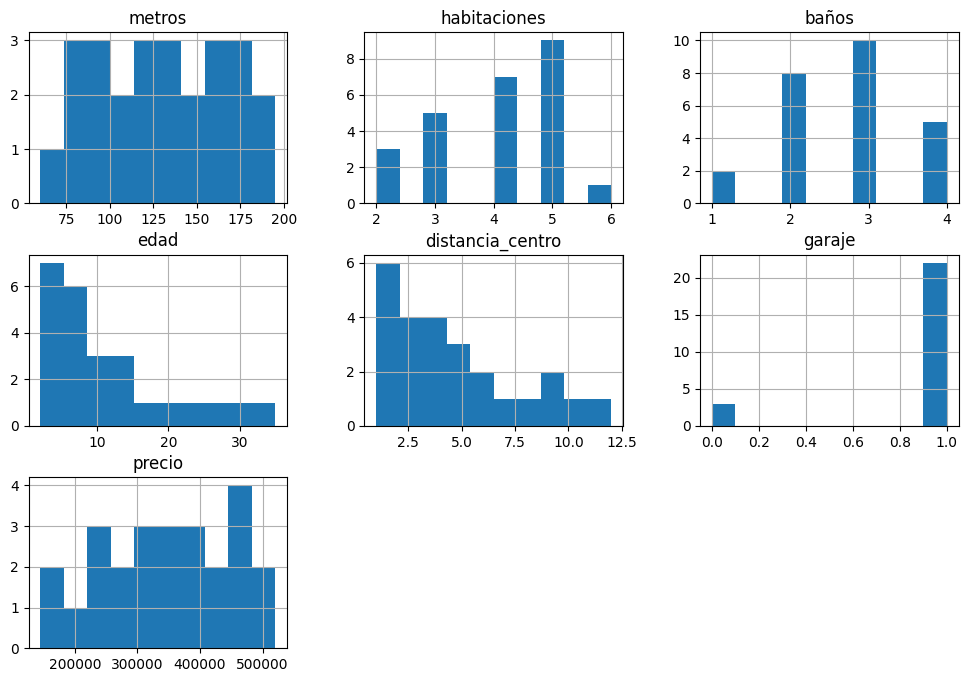

In [120]:
# Visualizar los datos

df.hist(figsize=(12,8))
plt.show()

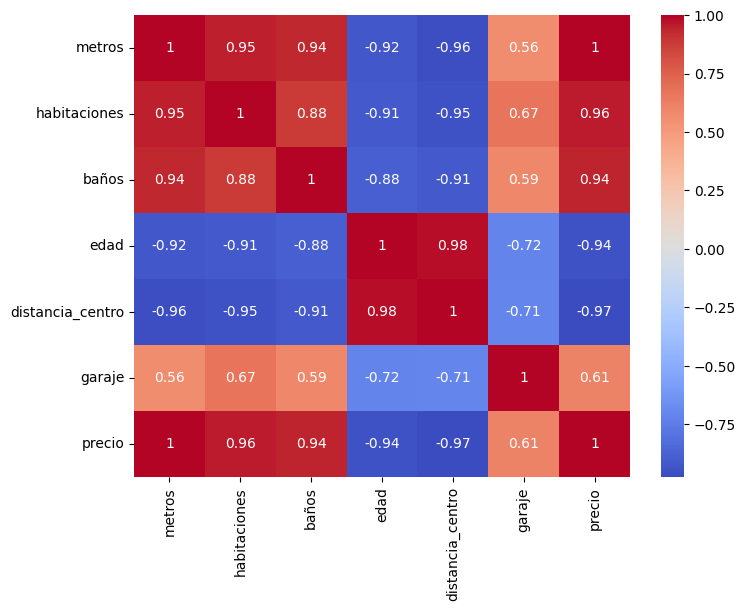

In [121]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

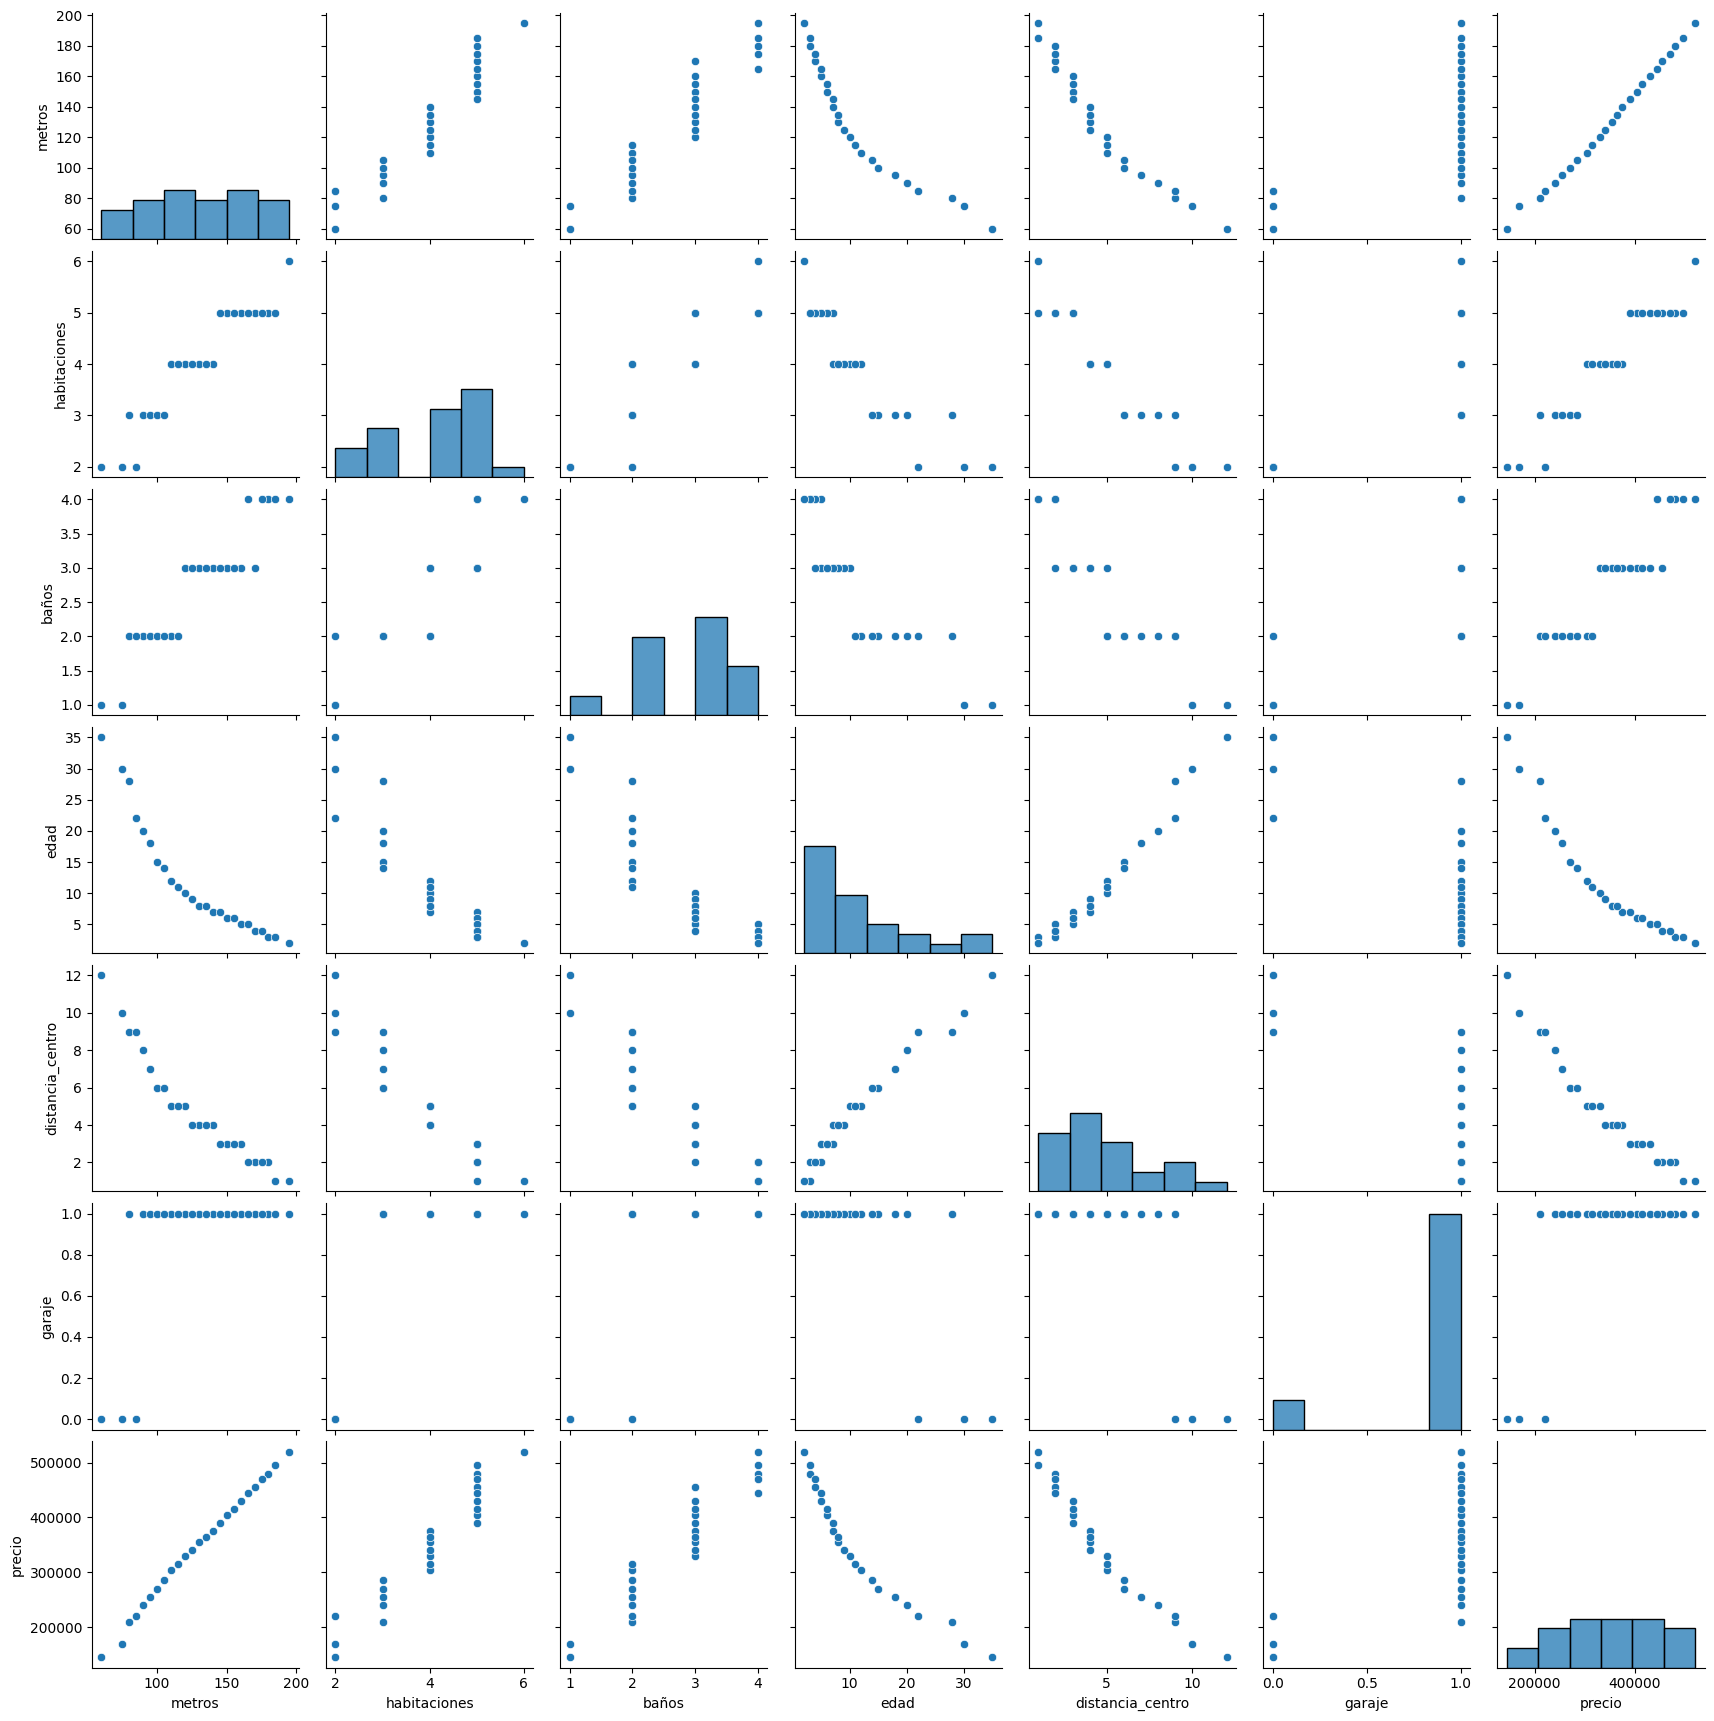

In [122]:
sns.pairplot(df)
plt.show()

In [123]:
# Definir los conjuntos de datos para las regresiones

X = df.drop("precio", axis=1) # me quedo con todo menos precio
y = df["precio"]

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.3,
    random_state=42
)

# no hace falta stratificacion por

In [125]:
# Normalización 

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # aprende media/desv de train
X_test_scaled  = scaler.transform(X_test)        # aplica lo aprendido


## Modelo RIDGE


In [126]:
# Algoritmo para detectar el alpha óptimo.
# Si el resultado es cercano a 0, el modelo se comporta de forma similar
# a una regresión lineal.

from sklearn.linear_model import RidgeCV

alphas = [0.001, 0.01, 0.05, 0.1, 1, 10, 100]

# Validación cruzada de 5 folds
ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5
)

# Entrenamiento
ridge_cv.fit(X_train_scaled, y_train)

# Mejor valor de alpha encontrado
print(f"Mejor valor de alpha: {ridge_cv.alpha_}")

Mejor valor de alpha: 0.01


In [127]:
ridge = Ridge(alpha=0.01) # el 1 es el punto de partida. 
ridge.fit(
    X_train_scaled,
    y_train
)


,alpha,0.01
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [128]:
# Predicciones

pred_ridge = ridge.predict(X_test_scaled)

In [129]:
# Ver métricas

print("MAE:", mean_absolute_error(y_test, pred_ridge))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, pred_ridge))
)

print(
    "R2:",
    r2_score(y_test, pred_ridge)
)

mape_ridge = mean_absolute_percentage_error(y_test, pred_ridge)

print(f"MAPE: {mape_ridge * 100:.2f}%")

MAE: 3135.727592049847
RMSE: 5731.631144590032
R2: 0.9978184720324053
MAPE: 1.52%


- **R²** = 0.997 — el modelo explica el 99,7% de la variabilidad del precio. Es un ajuste extremadamente alto, casi perfecto.
- **MAE** = 7.084,75 € — de media, el modelo se equivoca en unos 7.000 € al predecir el precio de una vivienda. Sobre un rango de precios de 145k-520k, es un error pequeño.
- **RMSE** = 5.731,63 € — algo más alto que el MAE, lo cual es normal (RMSE penaliza más los errores grandes). Que estén relativamente cerca (7.084 vs 8.423) indica que no hay ningún error puntual enorme distorsionando la métrica; los fallos del modelo son consistentes, no hay un "caso raro" muy mal predicho.
- **MAPE** = 1.52% — en términos de negocio, esta es la más fácil de comunicar a un director: "el modelo se desvía en promedio un 2,3% del precio real". Para una vivienda de 300.000 €, eso son ~7.000 €, coherente con el MAE.

### Con solo 25 viviendas en el dataset, un test set probablemente tiene entre 5 y 8 observaciones. Un R² de 0,995 con tan pocos datos de test no es tan fiable como parece: basta con que el split haya caído "fácil" (pocos casos atípicos en test) para que el número se infle. Antes de dar estos resultados por buenos yo comprobaría dos cosas:

- Validación cruzada (cross_val_score con cv=5) en lugar de un único train/test split, para ver si el R² se mantiene estable o varía mucho entre folds.
- Los coeficientes del modelo (ridge.coef_) — dado que detectamos antes posible colinealidad entre metros/habitaciones/baños, y que garaje aporta poca señal, vale la pena ver a qué variables les está dando más peso Ridge. 

## Modelo Lasso 

In [130]:
# Algoritmo para detectar el alpha

from sklearn.linear_model import LassoCV


# Validación cruzada de 5 folds
lasso_cv = LassoCV(
    cv=5,
    random_state=42
)

# Entrenamiento
lasso_cv.fit(X_train_scaled, y_train)

# Mejor valor de alpha encontrado
print(f"Mejor valor de alpha: {lasso_cv.alpha_}")

Mejor valor de alpha: 91.66664351442304


In [131]:
lasso = Lasso(alpha= 91.66664351442304)
lasso.fit(
    X_train_scaled,
    y_train
)

,alpha,91.66664351442304
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [132]:
# Predicciones

pred_lasso = lasso.predict(X_test_scaled)

In [133]:
# Ver métricas

print("MAE:", mean_absolute_error(y_test, pred_lasso))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, pred_lasso))
)

print(
    "R2:",
    r2_score(y_test, pred_lasso)
)

mape_ridge = mean_absolute_percentage_error(y_test, pred_lasso)

print(f"MAPE: {mape_ridge * 100:.2f}%")

MAE: 3168.961764444375
RMSE: 5909.1958163059835
R2: 0.9976812118051323
MAPE: 1.51%


In [134]:
# Comparación de ambos modelos

# Comparación de métricas

resultados = pd.DataFrame({
    "Modelo": ["Ridge", "Lasso"],
    "MAE": [
        mean_absolute_error(y_test, pred_ridge),
        mean_absolute_error(y_test, pred_lasso)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_ridge)),
        np.sqrt(mean_squared_error(y_test, pred_lasso))
    ],
    "MAPE (%)": [
        mean_absolute_percentage_error(y_test, pred_ridge) * 100,
        mean_absolute_percentage_error(y_test, pred_lasso) * 100
    ],
    "R2": [
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_lasso)
    ]
})

print(resultados)

  Modelo          MAE         RMSE  MAPE (%)        R2
0  Ridge  3135.727592  5731.631145  1.519200  0.997818
1  Lasso  3168.961764  5909.195816  1.514408  0.997681


In [135]:
# Comparación de coeficientes

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print(coeficientes)

           Variable         Ridge         Lasso
0            metros  76642.440468  78066.066696
1      habitaciones   2750.864771   2404.243989
2             baños   2084.196756   1730.871411
3              edad  -6349.043578  -6739.236781
4  distancia_centro  -4444.233402  -3181.829663
5            garaje    811.121189    930.442401


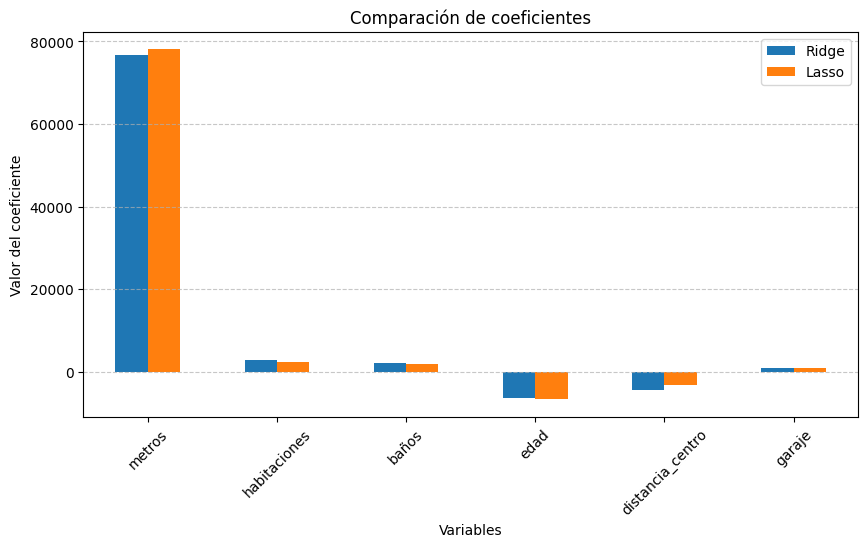

In [136]:
coeficientes.set_index("Variable").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparación de coeficientes")
plt.xlabel("Variables")
plt.ylabel("Valor del coeficiente")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

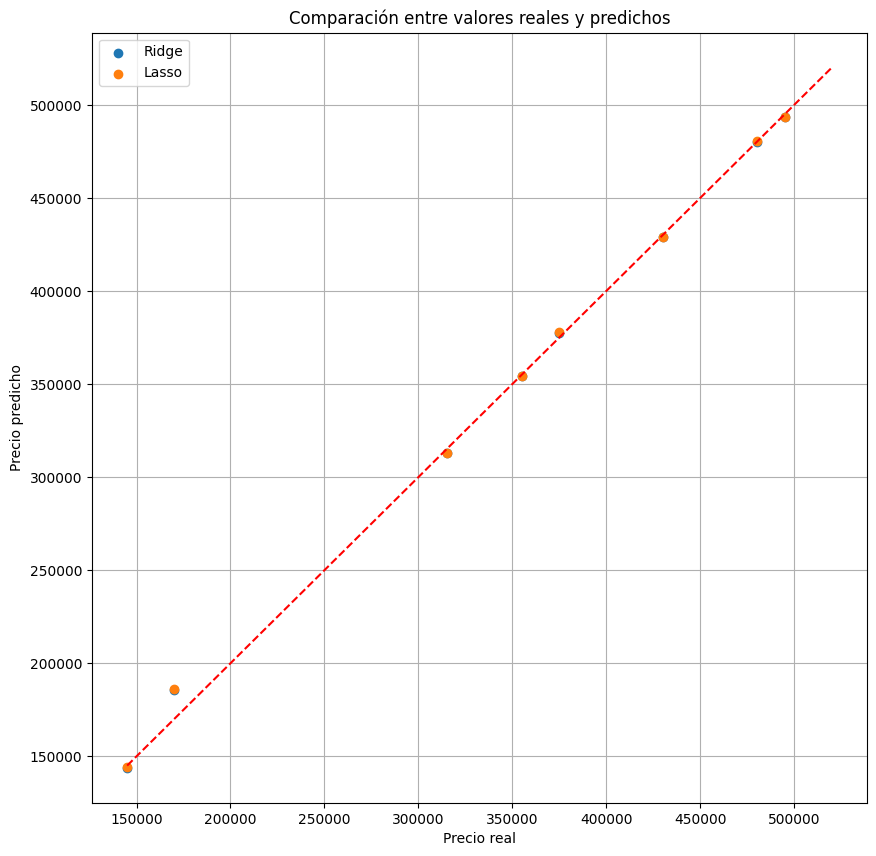

In [147]:
plt.figure(figsize=(10, 10))

plt.scatter(
    y_test,
    pred_ridge,
    label="Ridge"
)

plt.scatter(
    y_test,
    pred_lasso,
    label="Lasso"
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "r--"
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Comparación entre valores reales y predichos")

plt.legend()
plt.grid(True)

plt.show()

In [138]:
from sklearn.linear_model import LassoCV

# Rejilla amplia: si LassoCV eligiera el valor más bajo o más alto de la
# rejilla, sería señal de que el óptimo real cae fuera del rango probado.
alphas_lasso_cv = np.logspace(-2, 5.3, 60)

lasso_cv = LassoCV(alphas=alphas_lasso_cv, cv=5, max_iter=20000)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Mejor alpha (Lasso): {lasso_cv.alpha_:,.1f}")

lasso_opt = Lasso(alpha=lasso_cv.alpha_, max_iter=20000)
lasso_opt.fit(X_train_scaled, y_train)

pred_lasso_opt = lasso_opt.predict(X_test_scaled)

print("\nLasso con alpha óptimo")
print("MAE:", mean_absolute_error(y_test, pred_lasso_opt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lasso_opt)))
print("R2:", r2_score(y_test, pred_lasso_opt))
mape_lasso_opt = mean_absolute_percentage_error(y_test, pred_lasso_opt)
print(f"MAPE: {mape_lasso_opt * 100:.2f}%")

variables_activas = int((lasso_opt.coef_ != 0).sum())
print(f"Variables activas: {variables_activas} de {len(X.columns)}")

Mejor alpha (Lasso): 7.0

Lasso con alpha óptimo
MAE: 3180.2958038244105
RMSE: 5715.004053414844
R2: 0.9978311106169437
MAPE: 1.52%
Variables activas: 6 de 6


## Predicción del precio de una nueva vivienda

In [139]:
# Nueva vivienda a predecir
nueva = pd.DataFrame({
    "metros": [120],
    "habitaciones": [4],
    "baños": [2],
    "edad": [40],
    "distancia_centro": [2],
    "garaje": [1],
})[X.columns]  # fuerza el mismo orden de columnas que usó el scaler

In [140]:
nueva_scaled = scaler.transform(nueva)

In [141]:
precio_ridge = ridge.predict(nueva_scaled)
print("precio con ridge:", precio_ridge.round(4))
precio_lasso = lasso.predict(nueva_scaled)
print("precio con lasso", precio_lasso.round(4))

precio con ridge: [304018.1226]
precio con lasso [301098.4029]
